# 08 - Is the E family real retention, or a seeding artefact?

The E groups do not move: mean total displacement 0.1-1.2 deg over 180 days,
against 7.1 for S and 16.5 for B2. E2 alone is 5,897,277 trajectories, 38.6% of
the archive. Before that is reported as physical retention it needs ruling out
as an artefact - particles seeded in near-zero-velocity coastal cells, or stuck
against the land mask.

**The discriminating test is path length versus net displacement.**

* Genuine retention (eddy, recirculation, convergence): the particle *moves* -
  large cumulative path length, small net displacement. Ratio >> 1.
* Stuck (dead cell / land mask): the particle does not move at all - path
  length ~ 0 AND net ~ 0. Ratio undefined, speed ~ 0.

Net displacement alone cannot tell these apart, which is why the 5-day sampled
positions in the features file were not enough. This reads the FULL Zarr paths.

Secondary checks: release position relative to the coast, and the fraction of
observations with literally zero movement.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import config as C

# --- TUNE ME -----------------------------------------------------------------
N_PER_GROUP = 1500          # trajectories sampled per group
GROUPS = ["E2", "E1", "E0", "S", "B2", "F"]   # stationary ones + movers for contrast
ZERO_STEP_DEG = 1e-4        # a step smaller than this counts as "no movement"
# -----------------------------------------------------------------------------

N_IO_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", 16))
inv = {v: k for k, v in C.GROUP_NAMES.items()}
store_paths = {p.stem: p for p in C.list_stores()}
print("groups:", GROUPS, "| ids:", [inv[g] for g in GROUPS])

groups: ['E2', 'E1', 'E0', 'S', 'B2', 'F'] | ids: [10, 9, 8, 12, 4, 11]


## Sample trajectories per group
Equal numbers per group so the comparison is not dominated by E2's size.

In [2]:
lab = pd.read_parquet(C.LABELED_FILE,
                      columns=["trajectory_id", "store", "cluster_group", "status"])
lab = lab[(lab.status == "complete") & (lab.cluster_group >= 0)]

parts = []
for g in GROUPS:
    s = lab[lab.cluster_group == inv[g]]
    parts.append(s.sample(min(N_PER_GROUP, len(s)),
                          random_state=C.RANDOM_STATE).assign(grp=g))
pick = pd.concat(parts, ignore_index=True)
pick["local"] = pick.trajectory_id % C.TRAJ_PER_STORE
print(pick.grp.value_counts().to_string())
print(f"\ntotal {len(pick):,} trajectories from {pick.store.nunique()} stores")

grp
E2    1500
E1    1500
E0    1500
S     1500
B2    1500
F     1500

total 9,000 trajectories from 1509 stores


## Stream the full paths and measure movement
For every trajectory: cumulative path length, net displacement, mean/max step,
and the share of steps that are effectively zero. Degrees are converted to km
with a cos(lat) correction on longitude so speeds are comparable.

In [3]:
def _measure(name, grp):
    ds  = xr.open_zarr(store_paths[name])
    loc = grp.local.to_numpy()
    lat = ds.lat.values[loc]
    lon = ds.lon.values[loc]
    t   = ds.time.values[loc]
    out = []
    for k in range(len(loc)):
        ok = ~np.isnan(lon[k]) & ~np.isnat(t[k])
        if ok.sum() < 3:
            continue
        la, lo, tt = lat[k][ok], lon[k][ok], t[k][ok]
        dlat = np.diff(la)
        dlon = np.diff(lo) * np.cos(np.deg2rad((la[:-1] + la[1:]) / 2))
        step_deg = np.hypot(dlat, dlon)
        step_km  = step_deg * 111.32
        days = (tt[-1] - tt[0]) / np.timedelta64(1, "D")
        net_deg = np.hypot(la[-1] - la[0],
                           (lo[-1] - lo[0]) * np.cos(np.deg2rad((la[0] + la[-1]) / 2)))
        out.append(dict(
            trajectory_id=int(grp.trajectory_id.iloc[k]),
            rel_lat=float(la[0]), rel_lon=float(lo[0]),
            n_obs=int(ok.sum()), days=float(days),
            path_km=float(step_km.sum()), net_km=float(net_deg * 111.32),
            mean_step_km=float(step_km.mean()), max_step_km=float(step_km.max()),
            zero_frac=float((step_deg < ZERO_STEP_DEG).mean()),
            mean_speed_cms=float(step_km.sum() * 1e5 / (days * 86400)) if days > 0 else np.nan))
    return pd.DataFrame(out)

res = Parallel(n_jobs=N_IO_THREADS, backend="threading")(
    delayed(_measure)(name, grp) for name, grp in pick.groupby("store"))
mv = pd.concat([r for r in res if len(r)], ignore_index=True).merge(
    pick[["trajectory_id", "grp"]], on="trajectory_id")
print(f"measured {len(mv):,} trajectories")
mv.head()

measured 9,000 trajectories


,trajectory_id,rel_lat,rel_lon,n_obs,days,path_km,net_km,mean_step_km,max_step_km,zero_frac,mean_speed_cms,grp
0,4756,1.074526,-49.855007,740,184.75,568.739604,535.731882,0.769607,10.970006,0.830853,3.562996,E0
1,2035,0.469899,-49.451859,740,184.75,1639.835308,1281.444360,2.218992,12.212134,0.000000,10.273112,S
2,18067,1.057100,-49.843388,740,184.75,1613.743338,1258.000261,2.183685,10.291000,0.012179,10.109654,S
3,19232,0.966043,-49.782674,740,184.75,1620.014941,1252.637717,2.192172,12.135830,0.004060,10.148943,S
4,15308,0.030486,-49.158870,740,184.75,1647.611967,1217.387530,2.229516,11.143427,0.000000,10.321831,S


## The verdict table
`path/net` is the tell. A stuck particle has path_km ~ 0. A retained particle
has a large path_km with a small net_km, so the ratio blows up.

In [4]:
agg = mv.groupby("grp").agg(
    n=("path_km", "size"),
    path_km=("path_km", "median"),
    net_km=("net_km", "median"),
    speed_cms=("mean_speed_cms", "median"),
    max_step_km=("max_step_km", "median"),
    zero_frac=("zero_frac", "median"),
).reindex(GROUPS)
agg["path_over_net"] = (agg.path_km / agg.net_km).round(1)
print(agg.round(2).to_string())

print("\n--- interpretation ---")
for g in GROUPS:
    r = agg.loc[g]
    if r.path_km < 50:
        verdict = "STUCK - barely moves at all"
    elif r.path_over_net > 3:
        verdict = f"RETAINED - travels {r.path_km:,.0f} km but nets only {r.net_km:,.0f}"
    else:
        verdict = "TRANSPORTED - path and net comparable"
    print(f"  {g:3s} {verdict}")

        n  path_km   net_km  speed_cms  max_step_km  zero_frac  path_over_net
grp                                                                          
E2   1500   146.85   117.38       0.92         5.38       0.85            1.3
E1   1500   448.34   397.55       2.81         9.07       0.70            1.1
E0   1500   727.06   665.82       4.55        13.63       0.74            1.1
S    1500  1473.74  1125.89       9.23        11.34       0.00            1.3
B2   1500  3957.76  2773.29      24.79        23.35       0.00            1.4
F    1500  4655.35  1731.30      29.16        23.29       0.00            2.7

--- interpretation ---
  E2  TRANSPORTED - path and net comparable
  E1  TRANSPORTED - path and net comparable
  E0  TRANSPORTED - path and net comparable
  S   TRANSPORTED - path and net comparable
  B2  TRANSPORTED - path and net comparable
  F   TRANSPORTED - path and net comparable


## Distributions
Path length and mean speed per group. If E were an artefact its distribution
would sit against zero with no tail.

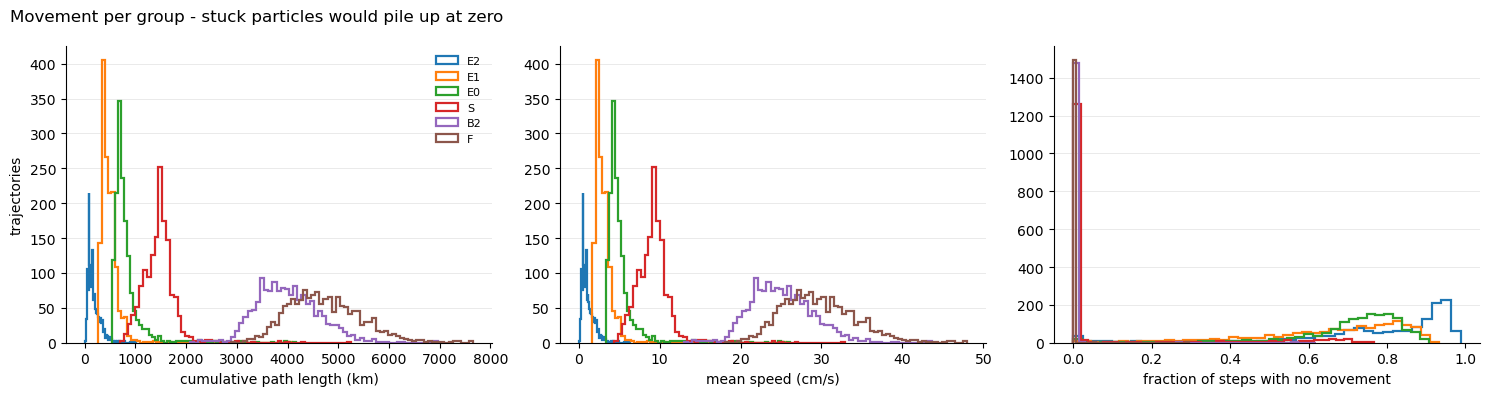

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for g in GROUPS:
    s = mv[mv.grp == g]
    axes[0].hist(s.path_km, bins=60, histtype="step", lw=1.6, label=g)
    axes[1].hist(s.mean_speed_cms, bins=60, histtype="step", lw=1.6, label=g)
    axes[2].hist(s.zero_frac, bins=40, histtype="step", lw=1.6, label=g)
axes[0].set_xlabel("cumulative path length (km)"); axes[0].set_ylabel("trajectories")
axes[1].set_xlabel("mean speed (cm/s)")
axes[2].set_xlabel("fraction of steps with no movement")
for a in axes:
    a.grid(axis="y", color="0.9", lw=.6); a.set_axisbelow(True)
    for sp in ("top", "right"): a.spines[sp].set_visible(False)
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("Movement per group - stuck particles would pile up at zero", x=.01,
             ha="left")
fig.tight_layout(); plt.show()

## Where are they released?
If the stationary groups were seeded in dead coastal cells, their release points
would sit systematically closer to land than the movers'. Distance is to the
nearest Natural Earth coastline vertex - coarse, but the comparison between
groups is what matters.

release distance to coast (km) and release position, by group:

     coast_km_median  coast_km_p10  rel_lat  rel_lon
grp                                                 
E2             28.33         10.33     0.61   -49.55
E1             22.77          8.04     0.82   -49.69
E0             26.89         11.01     0.84   -49.70
S              25.68          7.07     0.47   -49.45
B2             28.99         17.79     0.40   -49.41
F              30.74         16.65     0.42   -49.42


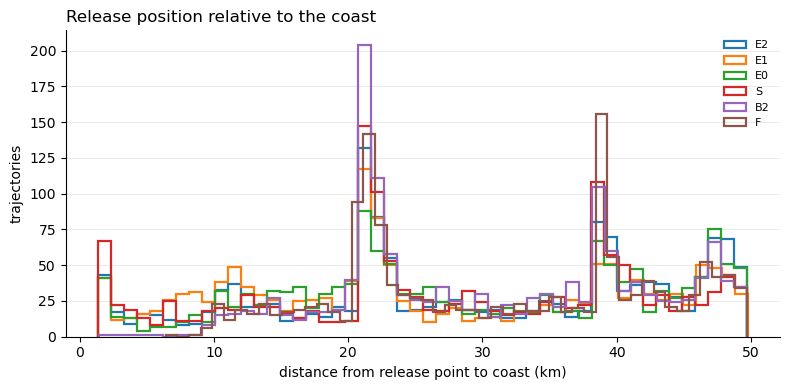

In [6]:
import cartopy.feature as cfeature
cx, cy = [], []
for geom in cfeature.COASTLINE.with_scale("50m").geometries():
    for line in getattr(geom, "geoms", [geom]):
        x, y = np.asarray(line.xy[0]), np.asarray(line.xy[1])
        cx.append(x); cy.append(y)
cx = np.concatenate(cx); cy = np.concatenate(cy)
box = (cx > -100) & (cx < 10) & (cy > -20) & (cy < 40)
cx, cy = cx[box], cy[box]

def _dist_to_coast(la, lo):
    d = np.hypot((cx[None, :] - lo[:, None]) * np.cos(np.deg2rad(la[:, None])),
                 cy[None, :] - la[:, None])
    return d.min(axis=1) * 111.32

mv["coast_km"] = _dist_to_coast(mv.rel_lat.to_numpy(), mv.rel_lon.to_numpy())
print("release distance to coast (km) and release position, by group:\n")
print(mv.groupby("grp").agg(
    coast_km_median=("coast_km", "median"),
    coast_km_p10=("coast_km", lambda s: s.quantile(.10)),
    rel_lat=("rel_lat", "median"),
    rel_lon=("rel_lon", "median")).reindex(GROUPS).round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for g in GROUPS:
    ax.hist(mv[mv.grp == g].coast_km, bins=50, histtype="step", lw=1.6, label=g)
ax.set_xlabel("distance from release point to coast (km)")
ax.set_ylabel("trajectories"); ax.legend(fontsize=8, frameon=False)
ax.grid(axis="y", color="0.9", lw=.6); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.set_title("Release position relative to the coast", loc="left")
fig.tight_layout(); plt.show()

## The decisive test - how long are they frozen, and where?
`zero_frac` above already separates the groups completely (0.70-0.85 for the E
family, 0.00 for every mover). This measures the *longest contiguous* frozen
run and the distance from the coast at the point where the particle stops.

Retention would freeze nowhere and drift everywhere. Beaching freezes once, on
the coast, and stays.


In [7]:
N_CHECK = 40      # trajectories per group for this (slow, per-trajectory) pass

cx, cy = [], []
for gm in cfeature.COASTLINE.with_scale("10m").geometries():
    for l in getattr(gm, "geoms", [gm]):
        cx.append(np.asarray(l.xy[0])); cy.append(np.asarray(l.xy[1]))
cx, cy = np.concatenate(cx), np.concatenate(cy)
_b = (cx > -90) & (cx < -30) & (cy > -15) & (cy < 25)
cx, cy = cx[_b], cy[_b]

def dist_coast(la, lo):
    d = np.hypot((cx[None, :] - lo[:, None]) * np.cos(np.deg2rad(la[:, None])),
                 cy[None, :] - la[:, None])
    return d.min(axis=1) * 111.32

rows = []
for g in GROUPS:
    ids = mv[mv.grp == g].sample(min(N_CHECK, (mv.grp == g).sum()),
                                 random_state=C.RANDOM_STATE).trajectory_id
    s = pick[pick.trajectory_id.isin(ids)]
    runs, finals = [], []
    for name, grp in s.groupby("store"):
        ds = xr.open_zarr(store_paths[name])
        for l in grp.local.to_numpy():
            lo, la = ds.lon.values[l], ds.lat.values[l]
            m = ~np.isnan(lo); lo, la = lo[m], la[m]
            step = np.hypot(np.diff(la),
                            np.diff(lo) * np.cos(np.deg2rad(la[:-1])))
            z = step < ZERO_STEP_DEG
            best = cur = 0
            for v in z:                      # longest contiguous frozen run
                cur = cur + 1 if v else 0
                best = max(best, cur)
            obs_step_d = 0.25                # 6-hourly output
            runs.append(best * obs_step_d)
            finals.append((la[-1], lo[-1]))
    finals = np.array(finals); dc = dist_coast(finals[:, 0], finals[:, 1])
    rows.append(dict(grp=g, frozen_med_d=np.median(runs), frozen_max_d=max(runs),
                     final_coast_km=np.median(dc),
                     pct_within_5km=100 * (dc < 5).mean()))
chk = pd.DataFrame(rows).set_index("grp").reindex(GROUPS)
print(chk.round(1).to_string())
print("\nfrozen_med_d = median longest continuous no-movement run, in days "
      f"(run length ~{mv.days.median():.0f} d)")

     frozen_med_d  frozen_max_d  final_coast_km  pct_within_5km
grp                                                            
E2          147.1         179.5             4.5            52.5
E1          105.6         164.5            16.0             5.0
E0          141.5         164.5            30.6            10.0
S             0.0         108.0             5.0            50.0
B2            0.0           5.2           149.2             5.0
F             0.0           0.0          1422.3             0.0

frozen_med_d = median longest continuous no-movement run, in days (run length ~185 d)


## Example paths
The stationary groups drawn at their own scale. A retained particle traces a
loop or a tangle; a stuck one is a dot.

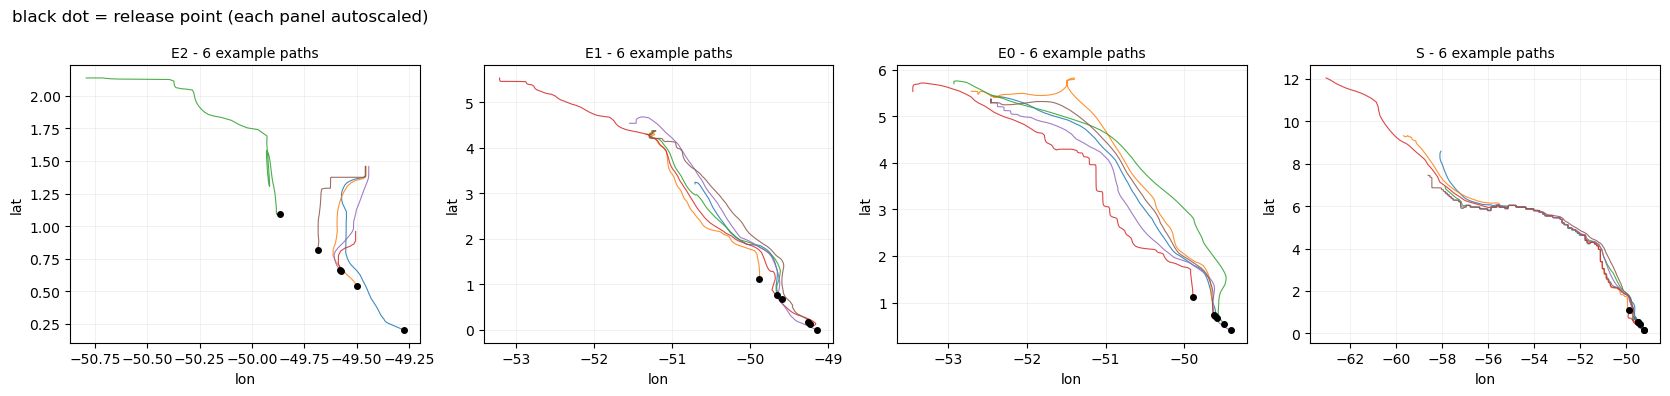

In [8]:
SHOW = [g for g in GROUPS if g in ("E2", "E1", "E0")][:3] + ["S"]
ex = {}
for g in SHOW:
    ids = mv[mv.grp == g].sample(min(6, (mv.grp == g).sum()),
                                 random_state=C.RANDOM_STATE).trajectory_id
    ex[g] = pick[pick.trajectory_id.isin(ids)]

fig, axes = plt.subplots(1, len(SHOW), figsize=(4.2 * len(SHOW), 4))
for ax, g in zip(np.atleast_1d(axes), SHOW):
    for name, grp in ex[g].groupby("store"):
        ds = xr.open_zarr(store_paths[name])
        for l in grp.local.to_numpy():
            lo, la = ds.lon.values[l], ds.lat.values[l]
            m = ~np.isnan(lo)
            ax.plot(lo[m], la[m], "-", lw=.8, alpha=.85)
            ax.plot(lo[m][0], la[m][0], "o", ms=4, color="k", zorder=3)
    ax.set_title(f"{g} - 6 example paths", fontsize=10)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    ax.grid(color="0.92", lw=.5); ax.set_axisbelow(True)
fig.suptitle("black dot = release point (each panel autoscaled)", x=.01, ha="left")
fig.tight_layout(); plt.show()

In [9]:
OUT = C.DATA_DIR / "retention_check.parquet"
mv.to_parquet(OUT, index=False)
print("saved", mv.shape, "->", OUT)

saved (9000, 13) -> /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_30_180_stdZ_w/data/retention_check.parquet


## Is the freezing seasonal?
Whether a particle *reaches* the coast is set by the circulation, so a seasonal
signal is expected and is a real result. Whether it *stays* there is set by the
boundary treatment. This measures the first over the whole archive, using a
proxy that needs no Zarr: position unchanged between the last two sampled days.


frozen between day 150 and 180: 7,310,647 of 15,266,266 = 47.9%

frozen rate per group:
     pct     size
E0  96.4   489782
E2  90.3  5897277
E1  83.4  1511437
S   13.2  1248144
S1   8.6   590429
B2   1.0  1944564
CB   1.0   384387
B1   0.6   385030
BS   0.5   579276
A3   0.4   154092
A2   0.3  1238761
C    0.1   512759
A1   0.0   150698
F    0.0   179630

by release month: 25.9% .. 68.0%  (ratio 2.63)
by release year : 43.2% .. 51.2%  (ratio 1.19)


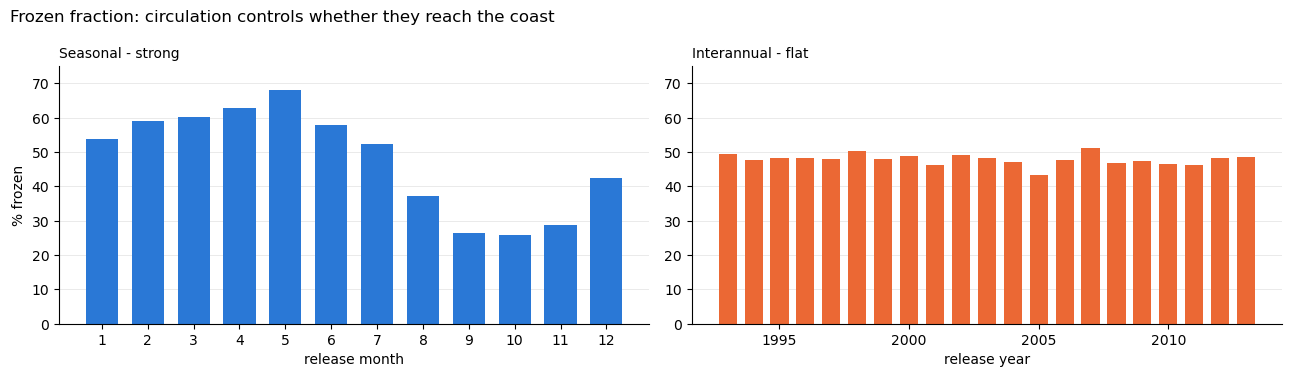

In [10]:
PROXY_KM = 1.0     # < this much movement between the last two sampled days = frozen

_c = (["cluster_group", "status", "release_month", "release_year"] +
      [f"{p}_{d}" for d in C.DAYS[-2:] for p in ("lat", "lon")])
full = pd.read_parquet(C.LABELED_FILE, columns=_c)
full = full[(full.status == "complete") & (full.cluster_group >= 0)]
d0, d1 = C.DAYS[-2], C.DAYS[-1]
_mv = np.hypot(full[f"lat_{d1}"] - full[f"lat_{d0}"],
               (full[f"lon_{d1}"] - full[f"lon_{d0}"])
               * np.cos(np.deg2rad(full[f"lat_{d0}"]))) * 111.32
full["frozen"] = _mv < PROXY_KM
print(f"frozen between day {d0} and {d1}: {full.frozen.sum():,} of {len(full):,} "
      f"= {100*full.frozen.mean():.1f}%\n")

by_g = full.groupby("cluster_group").frozen.agg(["mean", "size"])
by_g.index = [C.GROUP_NAMES[i] for i in by_g.index]
by_g["pct"] = (100 * by_g["mean"]).round(1)
print("frozen rate per group:")
print(by_g[["pct", "size"]].sort_values("pct", ascending=False).to_string())

mo = full.groupby("release_month").frozen.mean() * 100
yr = full.groupby("release_year").frozen.mean() * 100
print(f"\nby release month: {mo.min():.1f}% .. {mo.max():.1f}%  "
      f"(ratio {mo.max()/mo.min():.2f})")
print(f"by release year : {yr.min():.1f}% .. {yr.max():.1f}%  "
      f"(ratio {yr.max()/yr.min():.2f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(mo.index, mo.values, color="#2a78d6", width=.7)
axes[0].set_xticks(range(1, 13)); axes[0].set_xlabel("release month")
axes[0].set_ylabel("% frozen")
axes[0].set_title("Seasonal - strong", fontsize=10, loc="left")
axes[1].bar(yr.index, yr.values, color="#eb6834", width=.7)
axes[1].set_xlabel("release year")
axes[1].set_title("Interannual - flat", fontsize=10, loc="left")
for a in axes:
    a.set_ylim(0, 75); a.grid(axis="y", color="0.9", lw=.6); a.set_axisbelow(True)
    for s in ("top", "right"): a.spines[s].set_visible(False)
fig.suptitle("Frozen fraction: circulation controls whether they reach the coast",
             x=.01, ha="left")
fig.tight_layout(); plt.show()

## Absorbing or transient? The decisive test
If the coast were a physical retention zone, water that stalls there would
eventually rejoin the flow. If it is the land mask, a stalled particle is stuck
for good. This finds the first stationary interval of at least `FREEZE_DAYS`
and asks whether the particle ever moves meaningfully again - and how far.


In [11]:
FREEZE_DAYS = 5.0
OBS_STEP_D  = 0.25                       # 6-hourly output
FREEZE_OBS  = int(FREEZE_DAYS / OBS_STEP_D)
N_RESUME    = 250                        # trajectories per group

def _resume(name, grp):
    ds = xr.open_zarr(store_paths[name]); out = []
    for l in grp.local.to_numpy():
        lo, la = ds.lon.values[l], ds.lat.values[l]
        m = ~np.isnan(lo); lo, la = lo[m], la[m]
        if len(lo) < FREEZE_OBS + 5:
            continue
        step = np.hypot(np.diff(la), np.diff(lo) * np.cos(np.deg2rad(la[:-1])))
        z = step < ZERO_STEP_DEG
        runs = np.convolve(z.astype(int), np.ones(FREEZE_OBS, int), "valid")
        hit = np.where(runs == FREEZE_OBS)[0]
        if len(hit) == 0:
            out.append((False, False, np.nan)); continue
        after = step[hit[0] + FREEZE_OBS:]
        moved = after[after > 1e-3]
        resumed = bool(len(moved) > 10)
        out.append((True, resumed, float(moved.sum() * 111.32) if resumed else np.nan))
    return out

rows = []
for g in GROUPS:
    s = lab[lab.cluster_group == inv[g]].sample(N_RESUME, random_state=1).copy()
    s["local"] = s.trajectory_id % C.TRAJ_PER_STORE
    r = [x for part in Parallel(n_jobs=N_IO_THREADS, backend="threading")(
             delayed(_resume)(nm, gr) for nm, gr in s.groupby("store")) for x in part]
    fr = np.array([a for a, _, _ in r]); rs = np.array([b for _, b, _ in r])
    km = np.array([c for _, _, c in r])
    rows.append(dict(grp=g, n=len(r), froze_pct=100 * fr.mean(),
                     resumed_pct=100 * rs[fr].mean() if fr.any() else 0.0,
                     km_after=np.nanmedian(km[rs]) if rs.any() else np.nan))
res_tab = pd.DataFrame(rows).set_index("grp").reindex(GROUPS)
print(res_tab.round(1).to_string())
print("\nfroze_pct   = share with a stationary interval >= "
      f"{FREEZE_DAYS:.0f} days")
print("resumed_pct = of those, share that moved meaningfully again")
print("km_after    = median distance travelled after resuming")
print("\nA transient stall rejoins the circulation (large km_after);")
print("an absorbing one twitches and stops (small km_after).")

       n  froze_pct  resumed_pct  km_after
grp                                       
E2   250       98.8         16.2      20.1
E1   250       98.0         36.7      30.8
E0   250       99.2         12.5      33.7
S    250       18.8         23.4     936.0
B2   250        0.4          0.0       NaN
F    250        0.0          0.0       NaN

froze_pct   = share with a stationary interval >= 5 days
resumed_pct = of those, share that moved meaningfully again
km_after    = median distance travelled after resuming

A transient stall rejoins the circulation (large km_after);
an absorbing one twitches and stops (small km_after).
